# Práctica 03 (5%) Entrega Semana 6, 17:30 horas

#### Cargue el archivo nhanes_2015_2016.csv en un dataFrame y realice las siguientes exploraciones:

1. Usando la variable de estado civil [DMDMARTL](https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2015/DataFiles/DEMO_I.htm#DMDMARTL) agregue una nueva columna al dataFrame llamada "EstadoCivil" con los valores descriptivos para que tenga etiquetas informativas. 
1. Usando la variable RIAGENDR agregue una nueva columna al dataFrame llamada "Genero"con los valores descriptivos "Male" y "Female" (como lo hicimos en clases).
1. Restringiendo la muestra a la población femenina, estratifique a los sujetos en franjas de edad de diez años y construya la distribución del estado civil dentro de cada franja de edad. Presente la distribución en términos de proporciones que deben sumar 1. (Como lo hicimos al final de la clase al comparar grupos de edad con el nivel de educación).
1. Hacer lo mismo para la población masculina.
1. Construir histogramas separados para las alturas de mujeres y hombres usando la variable BMXHT
1. Construir un diagrama de caja (box plot) que muestre las alturas de mujeres y hombres.

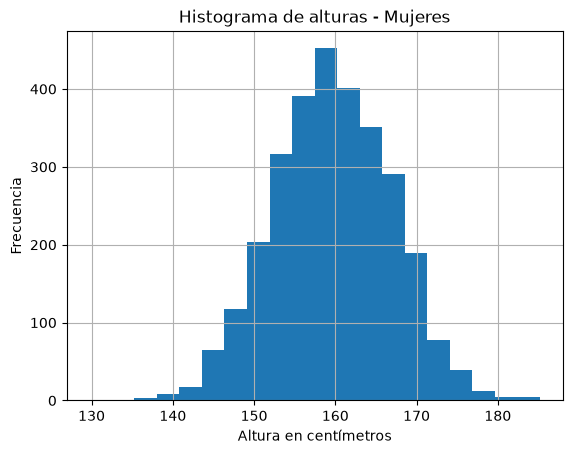

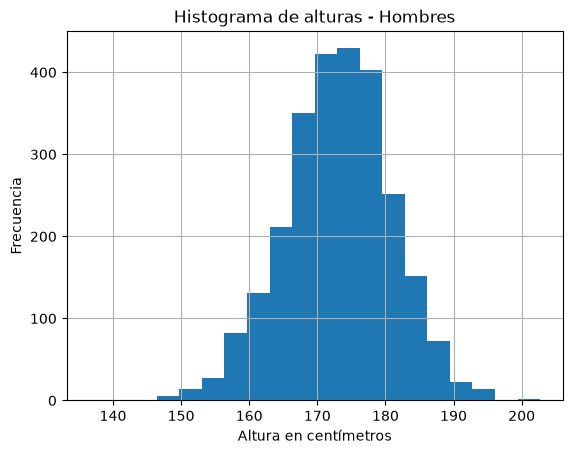

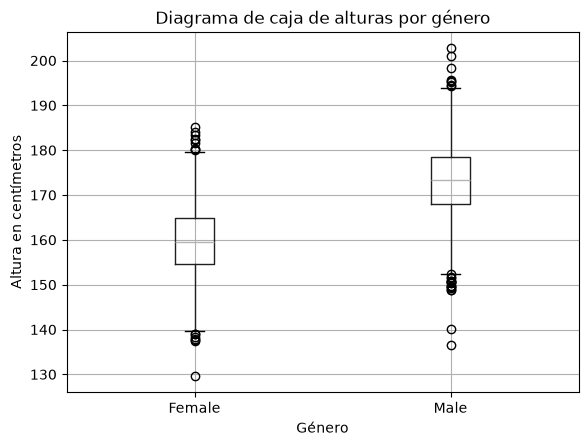

In [17]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("nhanes_2015_2016.csv")

# Primer ejercicio
estado_civil = {
    1: "Married",
    2: "Widowed",
    3: "Divorced",
    4: "Separated",
    5: "Never married",
    6: "Living with partner",
    77: "Refused",
    99: "Don't know"
}
df["EstadoCivil"] = df["DMDMARTL"].map(estado_civil)
df[["DMDMARTL", "EstadoCivil"]].head()

# Segundo ejercicio
genero = {
    1: "Male",
    2: "Female"
}
df["Genero"] = df["RIAGENDR"].map(genero)
df[["RIAGENDR", "Genero"]].head()

# Tercer ejercicio
bins = [20, 30, 40, 50, 60, 70, 80, 90]
labels = ["20-29", "30-39", "40-49", "50-59", "60-69", "70-79", "80+"]

df["FranjaEdad"] = pd.cut(df["RIDAGEYR"], bins=bins, labels=labels, right=False)

dfFemale = df[
    (df["Genero"] == "Female") &
    (df["EstadoCivil"].notna()) &
    (df["FranjaEdad"].notna())
].copy()

tabla_female = pd.crosstab(
    dfFemale["FranjaEdad"],
    dfFemale["EstadoCivil"],
    normalize="index"
)

tabla_female.round(3)

# Cuarto ejercicio
bins = [20, 30, 40, 50, 60, 70, 80, 90]
labels = ["20-29", "30-39", "40-49", "50-59", "60-69", "70-79", "80+"]

df["FranjaEdad"] = pd.cut(df["RIDAGEYR"], bins=bins, labels=labels, right=False)

dfMale = df[
    (df["Genero"] == "Male") &
    (df["EstadoCivil"].notna()) &
    (df["FranjaEdad"].notna())
].copy()

tabla_male = pd.crosstab(
    dfMale["FranjaEdad"],
    dfMale["EstadoCivil"],
    normalize="index"
)

tabla_male.round(3)

# Quinto ejercicio
dfFemale = df[
    (df["Genero"] == "Female")&
    (df["BMXHT"].notna())
].copy()
dfFemale["BMXHT"].hist(bins=20)
plt.title("Histograma de alturas - Mujeres")
plt.xlabel("Altura en centímetros")
plt.ylabel("Frecuencia")
plt.show()

dfMale["BMXHT"].hist(bins=20)

plt.title("Histograma de alturas - Hombres")
plt.xlabel("Altura en centímetros")
plt.ylabel("Frecuencia")
plt.show()

# Sexto ejercicio
df_alturas = df[
    (df["Genero"].isin(["Female", "Male"])) &
    (df["BMXHT"].notna())
].copy()

df_alturas.boxplot(
    column="BMXHT",
    by="Genero"
)

plt.title("Diagrama de caja de alturas por género")
plt.suptitle("")
plt.xlabel("Género")
plt.ylabel("Altura en centímetros")
plt.show()


#### Cargue el archivo starbucks_drinkMenu_expanded.csv en un dataFrame y realice las siguientes exploraciones:

1. Obtener una tabla que muestre los promedios de calorías agrupados por "Beverage_category" (Es similar a crear una tabla de frecuencias, pero en lugar de contar registros se calcula el promedio: "mean")
1. Construir un diagrama de caja que muestre la distribución de calorías, proteínas y carbohidratos.  
1. Construir un diagrama de caja que muestre la distribución de calorías, proteínas y carbohidratos solo para el caso donde "Beverage_category" es Smoothies.

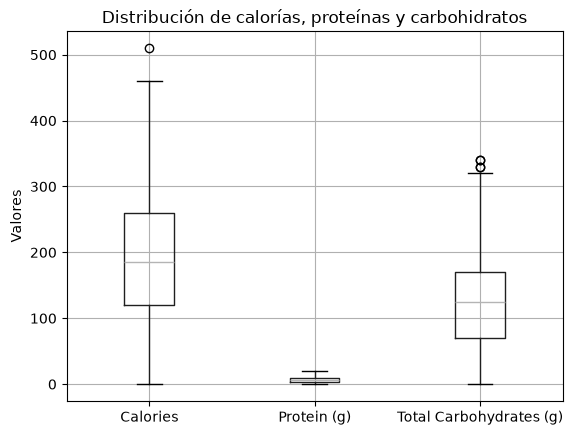

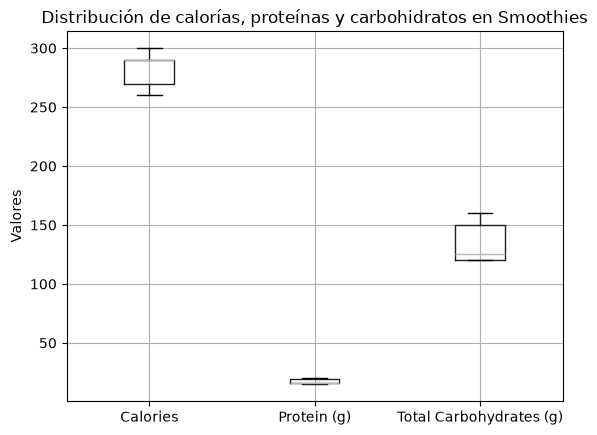

In [22]:
import pandas as pd
import matplotlib.pyplot as plt

dfStarbucks = pd.read_csv("starbucks_drinks.csv")
dfStarbucks.head()

# para limpiar espacios en blanco en los nombres
dfStarbucks.columns = dfStarbucks.columns.str.strip()

# primer ejercicio
promedio_calorias = dfStarbucks.groupby("Beverage_category")["Calories"].mean().round(2)
promedio_calorias

# segundo ejercicio
dfStarbucks[["Calories", "Protein (g)", "Total Carbohydrates (g)"]].boxplot()
plt.title("Distribución de calorías, proteínas y carbohidratos")
plt.ylabel("Valores")
plt.show()

# tercer ejercicio
dfSmoothies = dfStarbucks[dfStarbucks["Beverage_category"] == "Smoothies"].copy()
dfSmoothies[["Calories", "Protein (g)", "Total Carbohydrates (g)"]].boxplot()

plt.title("Distribución de calorías, proteínas y carbohidratos en Smoothies")
plt.ylabel("Valores")
plt.show()

#### Cargue el archivo EscuelaTech.csv en un dataFrame y realice las siguientes exploraciones:

1. Construir un diagrama de caja que permita comparar la distribución de las calificaciones de matemática por género y adecuación curricular
1. Construir tres histogramas uno para cada distribución de calificaciones (matemática, ciencias y literatura).

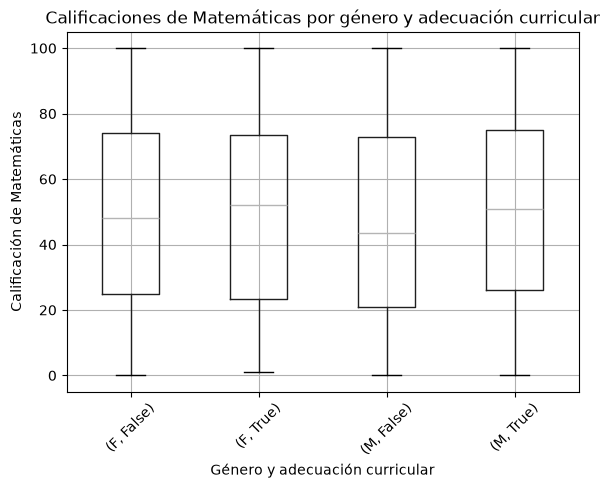

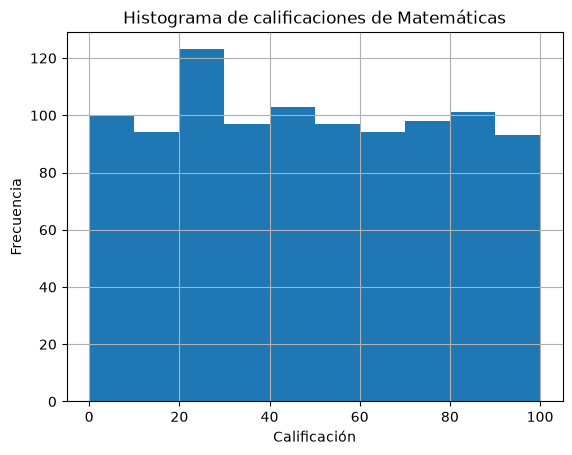

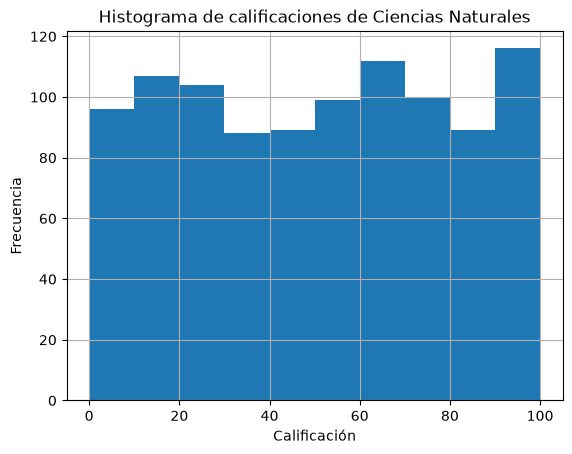

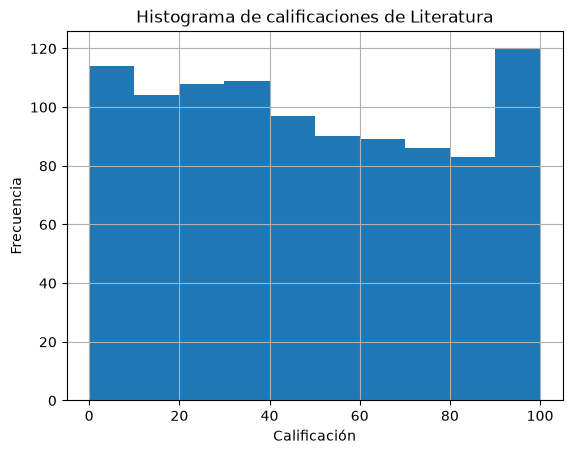

In [27]:
import pandas as pd
import matplotlib.pyplot as plt

dfEscuela = pd.read_csv("EscuelaTech.csv")

# Limpieza de posibles espacios en blanco en los nombres de las columnas
dfEscuela.columns = dfEscuela.columns.str.strip()

# Primer ejercicio

dfEscuela.boxplot(
    column="Calificación Matemáticas",
    by=["Género", "Adecuación Curricular"]
)

plt.title("Calificaciones de Matemáticas por género y adecuación curricular")
plt.suptitle("")
plt.xlabel("Género y adecuación curricular")
plt.ylabel("Calificación de Matemáticas")
plt.xticks(rotation=45)
plt.show()

# Segundo ejercicio

# Histograma de Matemáticas
dfEscuela["Calificación Matemáticas"].hist(bins=10)
plt.title("Histograma de calificaciones de Matemáticas")
plt.xlabel("Calificación")
plt.ylabel("Frecuencia")
plt.show()

# Histograma de Ciencias Naturales
dfEscuela["Calificación Ciencias Naturales"].hist(bins=10)
plt.title("Histograma de calificaciones de Ciencias Naturales")
plt.xlabel("Calificación")
plt.ylabel("Frecuencia")
plt.show()

# Histograma de Literatura
dfEscuela["Calificación Literatura"].hist(bins=10)
plt.title("Histograma de calificaciones de Literatura")
plt.xlabel("Calificación")
plt.ylabel("Frecuencia")
plt.show()